# Chapter 04 다양한 분류 알고리즘
## 04-2 확률적 경사 하강법
### 점진적인 학습
* 훈련 데이터가 한 번에 준비되는 것이 아니라 조금씩 전달됨. 도착하는 대로 생선을 판매해야 하므로 데이터가 쌓일 때까지 무작정 기다릴 수도 없음.
* 방법1: 기존의 훈련 데이터에 새로운 데이터를 추가하여 모델을 매일매일 다시 훈련하면?
  * 단점: 시간이 지날수록 데이터가 늘어남. 몇 달이 지나면 모델을 훈련하기 위해 서버를 늘려야 됨.
* 방법2: 새로운 데이터를 추가할 때 이전 데이터를 버림으로써 훈련 데이터 크기를 일정하게 유지
  * 단점: 데이터를 버릴 때 다른 데이터에 없는 중요한 생선 데이터가 포함되어 있다면 큰일.
* 위에서 언급한 방법은 이전에 훈련한 모델을 버리고 다시 새로운 모델을 훈련하는 방식. 앞서 훈련한 모델을 버리지 않고 새로운 데이터에 대해서만 조금씩 더 훈련할 수 없을까? -> **점진적 학습 또는 온라인 학습**
  * 대표적인 점진적 학습 알고리즘은 **확률적 경사 하강법Stochastic Gradient Descent**
#### 확률적 경사 하강법
* 경사 하강법
  * 가장 가파른 경사를 따라 원하는 지점에 도달하는 것이 목표
  * 가장 가파른 길을 찾아 내려오지만 조금씩 내려오는 것이 중요. 만약 한번에 걸음이 너무 크면 경사를 따라 내려가지 못하고 오히려 올라갈 수가 있음)
* 확률적: 가장 가파른 길을 찾을 때, 전체 샘플을 사용하지 않고 딱 하나의 샘플을 훈련 세트에서 랜덤하게 골라 가장 가파른 길을 찾음!
* **확률적 경사 하강법**
  * 훈련 세트에서 랜덤하게 하나의 샘플을 선택하여 가파른 경사를 조금 내려감. 그다음 훈련 세트에서 랜덤하게 또 다른 샘플을 하나 선택하여 경사를 조금 내려감. 이런 식으로 전체 샘플을 모두 사용할 때까지 계속.
  * 그래도 원하는 지점에 도달하지 못했다면? 다시 처음부터 시작!
  * 확률적 경사 하강법에서 훈련 세트를 한 번 모두 사용하는 과정을 **에포크epoch**라고 부름.
  * 일반적으로 경사 하강법은 수십, 수백 번 이상 에포크를 수행
* 1개씩 말고 무작위로 몇 개의 샘플ㅇ르 선택해서 경사를 따라 내려가면? -> 가능. 여러 개의 샘플을 사용해 경사 하강법을 수행하는 방식을 **미니배치 경사 하강법minibatch gradient descent**이라고 함. 실전에서 많이 사용.
* 극단적으로 한 번 경사로를 따라 이동하기 위해 전체 샘플을 사용할 수도. 이를 **배치 경사 하강법batch gradient descent**이라고 부름. 사실 전체 데이터를 사용하기 때문에 가장 안정적인 방법. 하지만 전체 데이터를 사용하면 컴퓨터 자원을 많이 사용. 어떤 경우는 데이터가 너무너무 많아 한 번에 전체 데이터를 모두 읽을 수 없을지도.


> 확률적 경사 하강법과 신경망 알고리즘
> * 확률적 경사 하강법을 꼭 사용하는 알고리즘이 있음. 바로 신경망 알고리즘. 신경망은 일반적으로 많은 데이터를 사용하기 때문에 한 번에 모든 데이터를 사용하기 어려움. 또 모델이 매우 복잡하기 때문에 수학적인 방법으로 해답을 얻기 어려움. 신경망 모델이 확률적 경사 하강법이나 미니배치 경사 하강법을 사용한다는 점을 꼭 기억!

#### 손실 함수
* **손실 함수loss function**
  * 어떤 문제에서 머신러닝 알고리즘이 얼마나 엉터리인지를 측정하는 기준 -> 손실 함수의 값이 작을수록 좋음. 하지만 어떤 값이 최솟값인지는 알지 못함. 가능한 많이 찾아보고 만족할만한 수준이라면 산을 다 내려왔다고 인정해야 함.


> 손실 함수와 비용 함수
> * 비용 함수(cost function)는 손실 함수의 다른 말. 엄밀히 말하면 손실 함수는 샘플 하나에 대한 손실을 정의하고 비용 함수는 훈련 세트에 있는 모든 샘플에 대한 손실 함수의 합. 하지만 보통 이 둘을 엄격히 구분하지 않고 섞어서 사용.

* 예를 들어, 4개의 샘플만 있다면 가능한 정확도는 0, 0.25, 0.5, 0.75, 1 다섯 가지 뿐. 정확도가 듬성듬성하다면 경사 하강법을 이용해 조금씩 움직일 수 없음. -> 기술적으로 말하면 손실 함수는 미분 가능해야 함!
* 어떻게 연속적인 손실 함수를 만들 수 있을까?
#### 로지스틱 손실 함수
* 또는 **이진 크로스엔트로피 손실 함수binary cross-entropy loss function**
* 다중 분류도 매우 비슷한 손실 함수를 사용 -> **크로스엔트로피 손실 함수cross-entropy loss function**

> 그럼 회귀에는 어떤 손실 함수를 사용할까요?
> * 회귀의 손실 함수로 3장에서 소개한 평균 절댓값 오차를 사용할 수 있음. 타깃에서 예측을 뺀 절댓값을 모든 샘플에 평균한 값. 또는 평균 제곱 오차(mean squared error)를 많이 사용. 타깃에서 예측을 뺀 값을 제곱한 다음 모든 샘플에 평균한 값. 확실히 이 값이 작을수록 좋은 모델.




####

### SGDClassifier

In [2]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [3]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

In [4]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [6]:
from sklearn.linear_model import SGDClassifier
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


* 훈련 세트와 테스트 세트 정확도가 낮음 -> 지정한 반복 횟수 10번이 부족한 것으로 보임
> ConvergenceWarning 경고가 뜨는데요?
> * 이 코드를 실행하면 사이킷런은 친절하게도 모델이 충분히 수렴하지 않았다는 ConvergenceWarning 경고를 보냄. 이런 경고를 보았다면 max_iter 매개변수의 값을 늘려 주는 것이 좋음.

* SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 더 훈련. 모델을 이어서 훈련할 때는 partial_fit() 메서드를 사용. 이 메서드는 fit() 메서드와 사용법이 같지만 호출할 때마다 1 에포크씩 이어서 훈련 가능.

In [8]:
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.7815126050420168
0.8


* 아직 점수가 낮지만 에포크를 한 번 더 실행하니 정확도가 향상되었음. 이 모델을 여러 에포크에서 더 훈련해 볼 필요가 있음. 그런데 얼마나 더 훈련해야 할까?
> 이건 배치 경사 하강법 아닌가요?
> * train_scaled와 train_target을 한꺼번에 모두 사용했으니 확률적 경사 하강법이 아닌 배치 경사 하강법이 아닌지? 아님. SGDClassifier 객체에 한 번에 훈련 세트 전체를 전달했지만 이 알고리즘은 전달한 훈련 세트에서 1개씩 샘플을 꺼내어 경사 하강법 단계를 수행. SGDClassifier는 미니배치 경사 하강법이나 배치 하강법을 제공하지 않음.

### 에포크와 과대/과소적합
* 확률적 경사 하강법을 사용한 모델은 에포크 횟수에 따라 과소적합이나 과대적합이 될 수 있음.
* 에포크 횟수가 적으면 모델이 훈련 세트를 덜 학습. 에포크 횟수가 충분히 많으면 훈련 세트를 완전히 학습.
* 적은 에포크 횟수 동안에 훈련한 모델은 훈련 세트와 테스트 세트에 잘 맞지 않는 과소적합된 모델일 가능성이 높음. <-> 많은 에포크 횟수 동안에 훈련한 모델은 훈련 세트에 너무 잘 맞아 테스트 세트에는 오히려 점수가 나쁜 과대적합된 모델일 가능성이 높음.
* 과대적합이 시작하기 전에 훈련을 멈추는 것을 **조기 종료early stopping**라고 함.

In [11]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

In [12]:
for _ in range(0, 300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

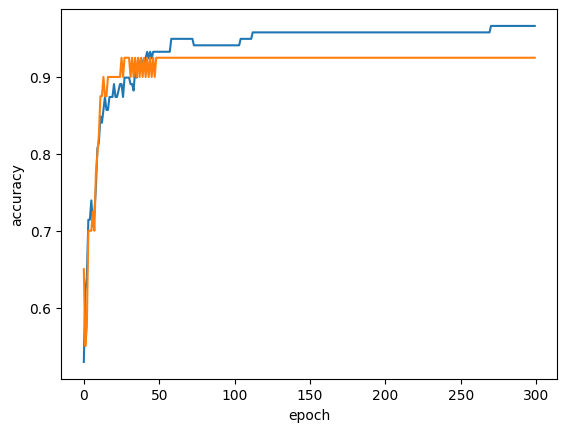

In [13]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

* 데이터가 작기 때문에 아주 잘 드러나지는 않지만, 백 번째 에포크 이후에는 훈련 세트와 테스트 세트의 점수가 조금씩 벌어지고 있음. 또 확실히 에포크 초기에는 과소적합되어 훈련 세트와 테스트 세트의 점수가 낮음. 이 모델의 경우 백 번째 에포크가 적절한 반복 횟수로 보임.

In [16]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


* SGDClassifier는 일정 에포크 동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춤. tol 매개변수에서 향상될 최솟값을 지정. None으로 지정하여 자동으로 멈추지 않고 max_iter=100 만큼 무조건 반복하도록.

> 확률적 경사 하강법을 사용한 분류 모델이 있다면 회귀 모델도 있나요?
> * 있음. SGDRegressor가 바로 확률적 경사 하강법을 사용한 회귀 알고리즘을 제공.
* 사실 loss 매개변수의 기본값은 'hinge'. **힌지 손실hinge loss**은 **서포트 벡터 머신support vector machine**이라 불리는 또 다른 머신러닝 알고리즘을 위한 손실 함수.
* 서포트 벡터 머신이 널리 사용하는 머신러닝 알고리즘 중 하나라는 점과 SGDClassifier가 여러 종류의 손실 함수를 loss 매개변수에 지정하여 다양한 머신러닝 알고리즘을 지원한다는 것만 기억!

In [17]:
sc = SGDClassifier(loss='hinge', max_iter=100,tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
